# Adım 8 — Zararsız relay'e karşı ayrım: projenin gerçek çöküş eğrisi

**Neden bu notebook var.** Adım 4/5'in grey eğrisi her `p` değerinde 0.8–1.0 arasında düzdü.
Adım 7 nedenini buldu: eğri **normale karşı** ölçülüyordu ve her grey-hole koşusunda ağda
fazladan bir relay vardı. Hiç paket düşürmeyen relay bile 40 koşunun hepsinde "atak"
işaretleniyordu (R0 = 1.000), yani eğri saldırıyı değil **relay'in varlığını** ölçüyordu.

**Bu notebook soruyu değiştiriyor:** ayrım `normal`'e karşı değil, **zararsız relay'e**
(grey `p=0`) karşı ölçülüyor.

| çerçeve | soru | sonuç |
|---|---|---|
| Adım 4/5 | "ağda bir aracı var mı?" | doygun — her `p`'de ~1.0 |
| **bu adım** | "bu aracı **kötü niyetli** mi?" | **gerçek çöküş eğrisi** |

> **Bu bir düzeltme değil, tercih.** Bir hastane güvenlik ekibi gerçekten "ağımda beklenmedik
> bir aracı var mı?" diye sorar ve detektör bunu **iyi** yapar; o meşru bir tespit görevidir.
> Buradaki çerçeve daha zor soruyu seçiyor ve doğal olarak daha düşük sayı üretiyor.
> Raporda ikisi de sunulmalı. (docs/23 §1)

In [1]:
# --- Kütüphaneler ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier

# --- Veri: eğitim seti + prob seti ---
# Zararsız relay (p=0) ve STA5'teki grey-hole grid'i EĞİTİM setinde yok, prob setinde.
# p=0 eğitime bilerek alınmadı (Issue 7): hiç düşürmeyen bir "grey-hole"u 'greyhole' diye
# etiketlemek tek vektöre iki anlam yüklemek olurdu. Burada tam da bu yüzden değerli.
def _find(*cands):
    p = next((Path(c) for c in cands if Path(c).exists()), None)
    assert p is not None, f"bulunamadi: {cands}"
    return p

TRAIN = _find("my-work/day3-4-08072026-09072026-dataset/out/dataset.csv",
              "../day3-4-08072026-09072026-dataset/out/dataset.csv")
PROBE = _find("my-work/day3-4-08072026-09072026-dataset/out_probes/dataset.csv",
              "../day3-4-08072026-09072026-dataset/out_probes/dataset.csv")
tr = pd.read_csv(TRAIN)
pr = pd.read_csv(PROBE)

# Feature listesi burada TANIMLANMIYOR, my-work/detector_schema.py'den geliyor.
# Kopyalanmis listeler birbirinden ayrilmisti: 02-07 bu ozellik eklenmeden once yazildi
# (12 girdi), 08-10 sonra (13), yayimlanan model 13. check_against_release() semayi
# yayimlanan manifest'e karsi dogruluyor -- buradaki sayilar teslim edilmis modeli
# anlatmiyorsa hucre patlar.
import sys
for _p in ("my-work", "..", "../.."):
    if (Path(_p)/"detector_schema.py").exists(): sys.path.insert(0, _p); break
from detector_schema import FEATURES, build_X, check_against_release
_rel = check_against_release()
print(f"sema surum {_rel['version']} ile uyusuyor ({len(_rel['model']['features'])} girdi)")

prep = build_X   # tek tanim: detector_schema.build_X

print(f"egitim {len(tr)} kosu | prob {len(pr)} kosu")
print("prob senaryolari:", dict(pr.scenario.value_counts()))

sema surum v1.1 ile uyusuyor (13 girdi)
egitim 285 kosu | prob 340 kosu
prob senaryolari: {'greypos': np.int64(110), 'mitm': np.int64(80), 'relaypos': np.int64(70), 'relay': np.int64(40), 'volmatch_ddos': np.int64(30), 'volmatch_dos': np.int64(10)}


## 1. Konum eşleştirmesi — neden pazarlık dışı

İlk turda taban yüksek çıktı (FA = 0.35) ve sebebini negatif sınıfın gürültülü olmasına
bağladım: STA8'deki zararsız relay iki tepeli — koşuların ~%28'i ilk burst'ü tamamen kaybedip
teslimde 0.773'e düşüyor.

Çözüm olarak **negatif sınıfı STA5'e taşıdım** (AP'ye 10 m, teslim 0.987) ama **pozitif sınıfı
STA8'de bıraktım**. Taban 0.350 → 0.075'e düştü, eğri keskinleşti. Çekici bir sonuçtu ve
**geçersizdi** — aşağıdaki kontrol deneyi nedenini gösteriyor.

Bu yüzden aşağıdaki her karşılaştırmanın **iki tarafı da aynı konumda**.

In [2]:
# --- Kontrol: iki ZARARSIZ relay, sirf konumdan ayirt edilebiliyor mu? ---
# Ikisi de p=0, ikisi de hicbir sey yapmiyor. Ayirt edilebiliyorlarsa, "STA5-zararsiz vs
# STA8-kotu" karsilastirmasi kotu niyetliligi degil MESAFEYI olcuyor demektir.
b8 = pr[pr.scenario == "relay"]                                   # zararsiz, STA8
b5 = pr[(pr.scenario == "relaypos") & (pr.intensity == 5)]        # zararsiz, STA5

ctrl = pd.concat([b8.assign(y="sta8"), b5.assign(y="sta5")], ignore_index=True)
ctrl_groups = ctrl.apply(lambda r: f"{r.y}_run{r.run}", axis=1)
ctrl_oof = cross_val_predict(
    RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=0),
    prep(ctrl), ctrl.y, cv=StratifiedGroupKFold(5, shuffle=True, random_state=0),
    groups=ctrl_groups)
ctrl_acc = (ctrl_oof == ctrl.y).mean()

print(f"STA8 vs STA5 (ikisi de ZARARSIZ) ayirt etme dogrulugu: {ctrl_acc:.3f}   [sans 0.50]")
print("-> Konum tek basina ayirt edilebiliyor. Bu yuzden negatif ve pozitif sinif")
print("   AYNI konumda olmali; yoksa detektore hak etmedigi kredi verilir.")

STA8 vs STA5 (ikisi de ZARARSIZ) ayirt etme dogrulugu: 0.762   [sans 0.50]
-> Konum tek basina ayirt edilebiliyor. Bu yuzden negatif ve pozitif sinif
   AYNI konumda olmali; yoksa detektore hak etmedigi kredi verilir.


## 2. İki kol — her biri konum eşleşmiş

- **Negatif sınıf:** grey `p=0` — relay var, tek paket bile düşürmüyor (40 tohum)
- **Pozitif sınıf:** grey `p>0` — **aynı konumdaki** relay, atak açık (11 config × 10 tohum)
- **Şema:** config-grupli dürüst değerlendirme. Pozitif taraf her `p` sırayla dışarıda
  bırakılarak (LOCO); negatif taraf tek config olduğu için koşu düzeyinde gruplu — `normal`
  ve `blackhole`'a uygulanan kuralın aynısı.

**STA8** = AP'ye en uzak (31.6 m) ve **kendi trafiği olmayan tek STA**.
**STA5** = AP'ye yakın (10.0 m); üzerinde 2 kbps'lik NIBP manşonu var, ihmal edilebilir.

In [3]:
def arm(benign, malicious, tag):
    """Bir konum kolu: zararsiz relay vs kotu niyetli relay, config-grupli OOF."""
    d = pd.concat([benign.assign(y="benign"), malicious.assign(y="malicious")],
                  ignore_index=True)
    groups = d.apply(lambda r: f"benign_run{r.run}" if r.y == "benign"
                               else f"grey_i{r.intensity}", axis=1)
    oof = cross_val_predict(
        RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=0),
        prep(d), d.y, cv=StratifiedGroupKFold(5, shuffle=True, random_state=0), groups=groups)
    d["pred"] = oof
    fa = (d[d.y == "benign"].pred == "malicious").mean()
    curve = (d[d.y == "malicious"].groupby("intensity")
               .agg(n=("pred", "size"),
                    tespit=("pred", lambda s: (s == "malicious").mean()),
                    delivery=("delivery_ratio", "median"))
               .reset_index())
    curve["taban_ustu"] = curve.tespit - fa
    over = curve[curve.taban_ustu >= 0.50]
    collapse = over.intensity.min() if len(over) else None
    print(f"\n=== {tag} ===")
    print(f"  zararsiz relay: n={len(benign)}  delivery medyan {benign.delivery_ratio.median():.3f}"
          f"  IQR {benign.delivery_ratio.quantile(.75) - benign.delivery_ratio.quantile(.25):.3f}")
    print(f"  YANLIS ALARM TABANI: {fa:.3f}")
    print(curve.round(3).to_string(index=False))
    print(f"  -> cokus noktasi (taban ustu >= 0.50): p = {collapse}")
    return {"fa": fa, "curve": curve, "collapse": collapse,
            "benign_delivery": benign.delivery_ratio.median()}

ARMS = {
    "STA8 (31.6 m)": arm(b8, tr[tr.scenario == "greyhole"], "STA8 — AP'ye en uzak"),
    "STA5 (10.0 m)": arm(b5, pr[pr.scenario == "greypos"],  "STA5 — AP'ye yakin"),
}


=== STA8 — AP'ye en uzak ===
  zararsiz relay: n=40  delivery medyan 0.883  IQR 0.174
  YANLIS ALARM TABANI: 0.350
 intensity  n  tespit  delivery  taban_ustu
      0.02 10     0.4     0.929        0.05
      0.05 10     0.7     0.887        0.35
      0.10 10     0.9     0.858        0.55
      0.20 10     1.0     0.754        0.65
      0.30 10     1.0     0.653        0.65
      0.40 10     1.0     0.576        0.65
      0.50 10     1.0     0.476        0.65
      0.60 10     1.0     0.384        0.65
      0.70 10     1.0     0.285        0.65
      0.80 10     1.0     0.191        0.65
      0.90 10     1.0     0.090        0.65
  -> cokus noktasi (taban ustu >= 0.50): p = 0.1



=== STA5 — AP'ye yakin ===
  zararsiz relay: n=40  delivery medyan 0.969  IQR 0.060
  YANLIS ALARM TABANI: 0.225
 intensity  n  tespit  delivery  taban_ustu
      0.02 10     0.2     0.961      -0.025
      0.05 10     0.7     0.929       0.475
      0.10 10     1.0     0.882       0.775
      0.20 10     1.0     0.771       0.775
      0.30 10     1.0     0.684       0.775
      0.40 10     1.0     0.587       0.775
      0.50 10     1.0     0.495       0.775
      0.60 10     1.0     0.389       0.775
      0.70 10     1.0     0.292       0.775
      0.80 10     1.0     0.196       0.775
      0.90 10     1.0     0.091       0.775
  -> cokus noktasi (taban ustu >= 0.50): p = 0.1


## 3. Figür — iki panel

**Sol (tespit uzayı):** `p`'ye göre "kötü niyetli" denme oranı, her konum için kendi yanlış-alarm
tabanıyla. Taralı alan = **atağın gerçek katkısı** (tabanın üstü). Eğri tabana değdiği yerde
saldırı görünmez demektir.

**Sağ (feature uzayı):** aynı `p` ekseninde `delivery_ratio`, ve zararsız relay'in kendi teslimi
yatay çizgi olarak. Sol panelin neden o şekli aldığını açıklıyor: tespit, saldırının teslimi
zararsız relay'in teslim bandından ayrıldığı yerde başlıyor.

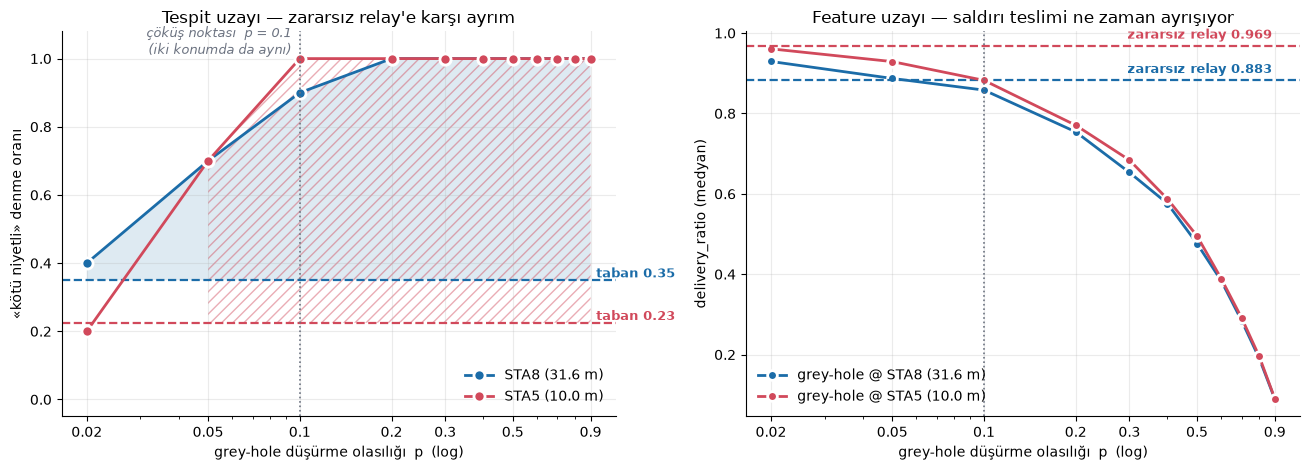

In [4]:
# --- Palet (dataviz validator: 5/5 PASS, CVD dE 12.4 protan) ---
C = {"STA8 (31.6 m)": "#1b6ca8",   # mavi
     "STA5 (10.0 m)": "#d1495b"}   # kirmizi
C_INK = "#6b7280"

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8))
XT = [0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.9]

# ================= Panel 1: tespit uzayi =================
ax = axes[0]
# Iki dolgu ust uste bindiginde renkleri karisip camurlu bir ton uretiyor; ikincisine
# duz dolgu yerine hatch veriyoruz. Hatch rengi facecolor'dan degil EDGECOLOR'dan gelir,
# ve facecolor="none" olmali -- alpha=0 vermek yamanin tamamini (hatch dahil) gorunmez yapar.
# Bu ayni zamanda ikincil kodlama: CVD ve gri baskida iki bolge renk olmadan da ayrilir.
FILL = {"STA8 (31.6 m)": lambda col: dict(facecolor=col, edgecolor="none", alpha=0.14),
        "STA5 (10.0 m)": lambda col: dict(facecolor="none", edgecolor=col, alpha=0.45,
                                          hatch="///")}
for tag, r in ARMS.items():
    col, c = C[tag], r["curve"]
    xs, ys = c.intensity.to_numpy(), c.tespit.to_numpy()
    # Taban ustu = atagin gercek katkisi. Tabanin ALTINA inen kisim taranmaz --
    # orada atak, zararsiz relay'den daha az isaretleniyor demek.
    ax.fill_between(xs, r["fa"], ys, where=ys >= r["fa"], lw=0, **FILL[tag](col))
    ax.axhline(r["fa"], color=col, lw=1.6, ls="--")
    ax.plot(xs, ys, "o-", color=col, lw=2, ms=8, label=tag,
            markeredgecolor="white", markeredgewidth=2)
    ax.annotate(f"taban {r['fa']:.2f}", xy=(0.9, r["fa"]), xytext=(4, 2),
                textcoords="offset points", color=col, fontsize=9, fontweight="bold")

# Cokus noktasi ikisinde de ayni -> tek dikey isaret. Yazi UST BOSLUGA konuyor:
# p<=0.1 bolgesinde egriler 0.9'un altinda, dolayisiyla ust serit bos.
cp = ARMS["STA8 (31.6 m)"]["collapse"]
ax.axvline(cp, color=C_INK, lw=1.2, ls=":")
ax.annotate(f"çöküş noktası  p = {cp}\n(iki konumda da aynı)", xy=(cp, 1.05), xytext=(-6, 0),
            textcoords="offset points", color=C_INK, fontsize=9.5, style="italic",
            ha="right", va="center")

ax.set_xscale("log"); ax.set_xticks(XT); ax.set_xticklabels([str(t) for t in XT])
ax.set_ylim(-0.05, 1.08)
ax.set_xlabel("grey-hole düşürme olasılığı  p  (log)")
ax.set_ylabel("«kötü niyetli» denme oranı")
ax.set_title("Tespit uzayı — zararsız relay'e karşı ayrım")
ax.grid(alpha=0.25); ax.legend(loc="lower right", frameon=False)
for s in ("top", "right"): ax.spines[s].set_visible(False)

# ================= Panel 2: feature uzayi =================
ax = axes[1]
for tag, r in ARMS.items():
    col, c = C[tag], r["curve"]
    ax.plot(c.intensity, c.delivery, "o-", color=col, lw=2, ms=7, label=f"grey-hole @ {tag}",
            markeredgecolor="white", markeredgewidth=2)
    ax.axhline(r["benign_delivery"], color=col, lw=1.6, ls="--")
    # Etiketler SAG UCA: orada egriler 0.09'a inmis, ust serit bos. Sol uca konunca
    # STA8 etiketi kendi egrisinin uzerine biniyordu.
    ax.annotate(f"zararsız relay {r['benign_delivery']:.3f}", xy=(0.9, r["benign_delivery"]),
                xytext=(-2, 5), textcoords="offset points", color=col, fontsize=9,
                ha="right", fontweight="bold")

ax.axvline(cp, color=C_INK, lw=1.2, ls=":")
ax.set_xscale("log"); ax.set_xticks(XT); ax.set_xticklabels([str(t) for t in XT])
ax.set_xlabel("grey-hole düşürme olasılığı  p  (log)")
ax.set_ylabel("delivery_ratio (medyan)")
ax.set_title("Feature uzayı — saldırı teslimi ne zaman ayrışıyor")
ax.grid(alpha=0.25); ax.legend(loc="lower left", frameon=False)
for s in ("top", "right"): ax.spines[s].set_visible(False)

fig.tight_layout()
FIGS = Path("figs"); FIGS.mkdir(exist_ok=True)
fig.savefig(FIGS / "M-zararsiz-relaye-karsi-ayrim.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Okuma

**Çöküş noktası her iki konumda da `p = 0.1`.** Sonuç relay'in nereye konduğuna karşı sağlam —
§1'deki kontrol deneyinden sonra bu ayrıca test edilmesi gereken bir şeydi.

**Rapora girecek ifade:**

> Bir grey-hole'ün, yol üzerindeki **zararsız** bir aracıdan ayırt edilebilmesi için paketlerin
> en az **%5–10'unu** düşürmesi gerekiyor. Bunun altında saldırı, zararsız bir relay'in kendi
> gürültüsünün içinde kalıyor: AP'ye yakın konumda %2 düşüren bir grey-hole, hiç düşürmeyen
> relay'den **daha az** sıklıkla işaretleniyor (taban üstü −0.025).

**Uzak relay saldırıyı maskeliyor.** STA8'de zararsız relay'in teslimi zaten 0.883'e düşmüş ve
`p=0.1`'in 0.858'iyle neredeyse çakışıyor; STA5'te ise zararsız relay 0.969'da ve dar, `p=0.1`'in
0.882'sinden net ayrılıyor. Bu yüzden eğri STA5'te daha keskin (taban üstü 0.775 vs 0.65).

**Temiz negatif sınıfın katkısı gerçek ama mütevazı:** taban 0.350 → 0.225. (Konum confound'lu
ölçümdeki sahte 0.075 değil.)

Ayrıntı ve MITM kolunun neden bu çerçevede de çalışmadığı: **docs/23**.